# Regresion Lineal del Costo del Seguro

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
dataset_original = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/insurance.csv')
print('El tamaño del dataset es de:', dataset_original.shape)
dataset_original.head()

El tamaño del dataset es de: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Charges es nuestro Y, ya que queremos predecir el costo de nuestro seguro dependiendo de los factores principalmente.
Los factores son:


*   Age:
*   Sex:
*   BMI: Body mass index, idealmente debería estar entre 18.5 y 24.9
*   Smoker: Si fuma o no la persona
*   Region: El area donde vive la persona beneficiaria

In [ ]:
#Encontrar valores nulos en la base de datos
dataset_original.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### Pre processing

In [ ]:
dataset_original.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [5]:
#Imprimir los valores que tiene region
valores_unicos = dataset_original['region'].unique()
print(valores_unicos)

['southwest' 'southeast' 'northwest' 'northeast']


In [ ]:
dataset_original['sex'] = dataset_original['sex'].map({'male': 0, 'female': 1})
dataset_original['smoker'] = dataset_original['smoker'].map({'no': 0, 'yes': 1})
dataset_original['region'] = dataset_original['region'].map({'southwest': 0, 'southeast': 1, 'northwest': 2, 'northeast': 3})
dataset_original.dtypes

age           int64
sex           int64
bmi         float64
children      int64
smoker        int64
region        int64
charges     float64
dtype: object

In [ ]:
dataset_original.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,0,16884.92400
1,18,0,33.770,1,0,1,1725.55230
2,28,0,33.000,3,0,1,4449.46200
3,33,0,22.705,0,0,2,21984.47061
4,32,0,28.880,0,0,2,3866.85520


Imprimiremos un Heatmap de las correlaciones para encontrar valores que tengan mucha correlación entre ellos y encontrar predicciones con esos valores principalmente.

Text(0.5, 1.0, 'Matriz de correlación de nuestro DATASET')

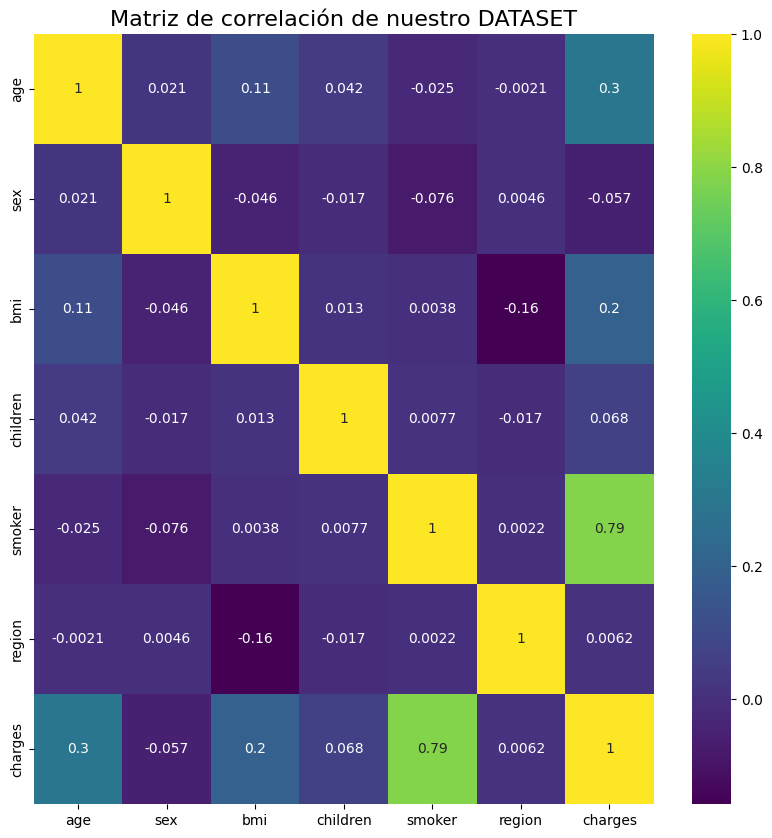

In [ ]:
f, ax = plt.subplots(1, 1, figsize=(10, 10))
ax = sns.heatmap(dataset_original.corr(), annot=True, cmap='viridis')
ax.set_title('Matriz de correlación de nuestro DATASET', fontsize=16)


Encontramos una correlación muy alta con el 'smoker' y además se puede obtener algo con el age y bmi.

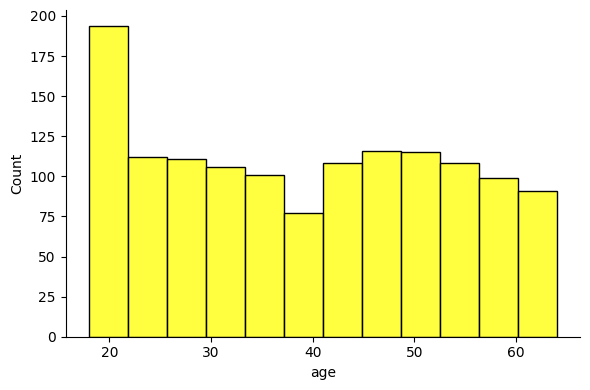

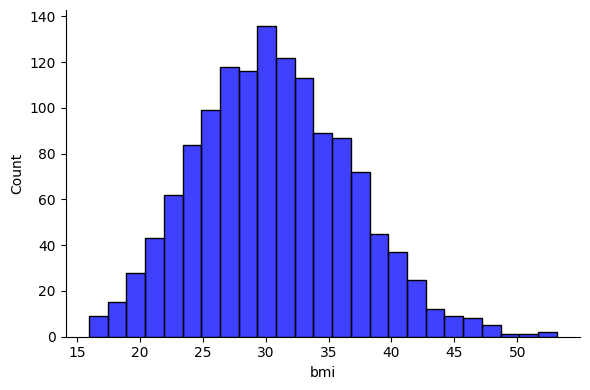

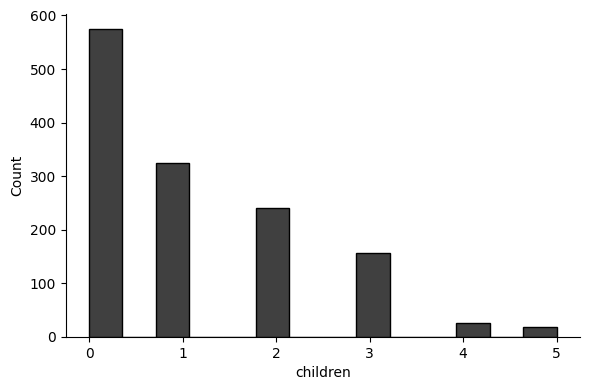

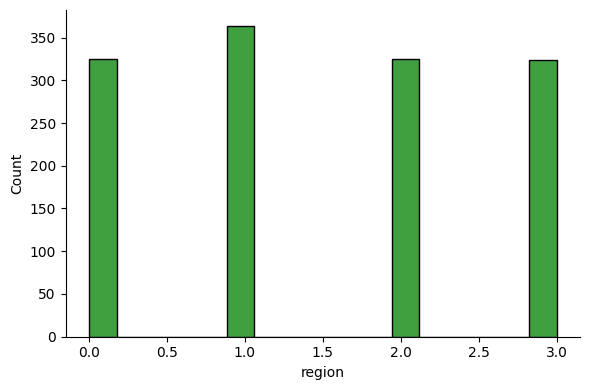

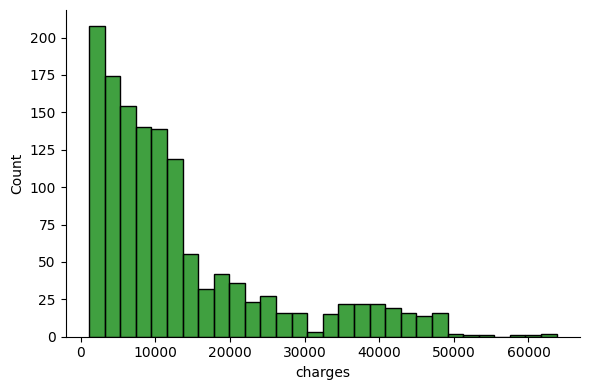

In [ ]:
import seaborn as sns

g1 = sns.displot(dataset_original, color = 'yellow', x="age", height=4, aspect=1.5)
#g2 = sns.displot(dataset_original, color = 'red', x="sex", height=4, aspect=1.5)
g3 = sns.displot(dataset_original, color = 'blue', x="bmi", height=4, aspect=1.5)
g4 = sns.displot(dataset_original, color = 'black', x="children", height=4, aspect=1.5)
#g5 = sns.displot(dataset_original, color = 'green', x="smoker", height=4, aspect=1.5)
g6 = sns.displot(dataset_original, color = 'green', x="region", height=4, aspect=1.5)
g7 = sns.displot(dataset_original, color = 'green', x="charges", height=4, aspect=1.5)



Encontramos costos impresionantes de $60,000$ y $50,000$ que pueden llegar a desbalancear la relación, además que son a muy pocas personas, por lo que se optó por cortarlo, así como valores de bmi impresionantes de 50, los cuáles se salen de la métrica tratada anteriormente.

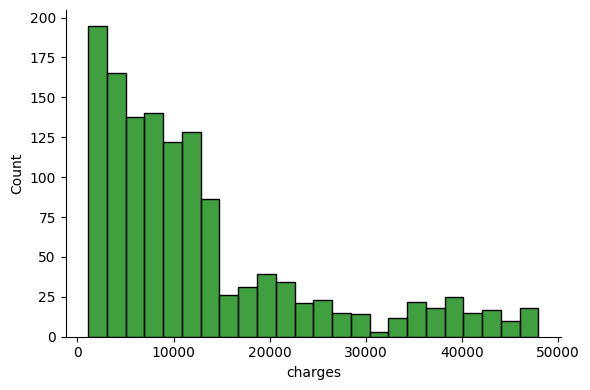

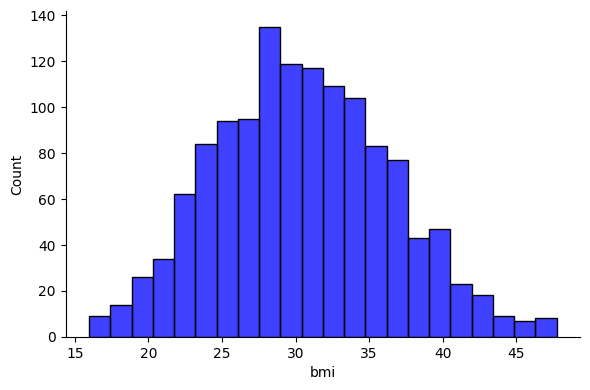

In [6]:
dataset_edit = dataset_original.copy()
dataset_edit = dataset_edit[dataset_edit['charges'] <= 48000]
dataset_edit = dataset_edit[dataset_edit['bmi'] <= 48]

g1 = sns.displot(dataset_edit, color = 'green', x="charges", height=4, aspect=1.5)
g1 = sns.displot(dataset_edit, color = 'blue', x="bmi", height=4, aspect=1.5)


Volvemos a comparar la correlación

Text(0.5, 1.0, 'Matriz de correlación de datos editados')

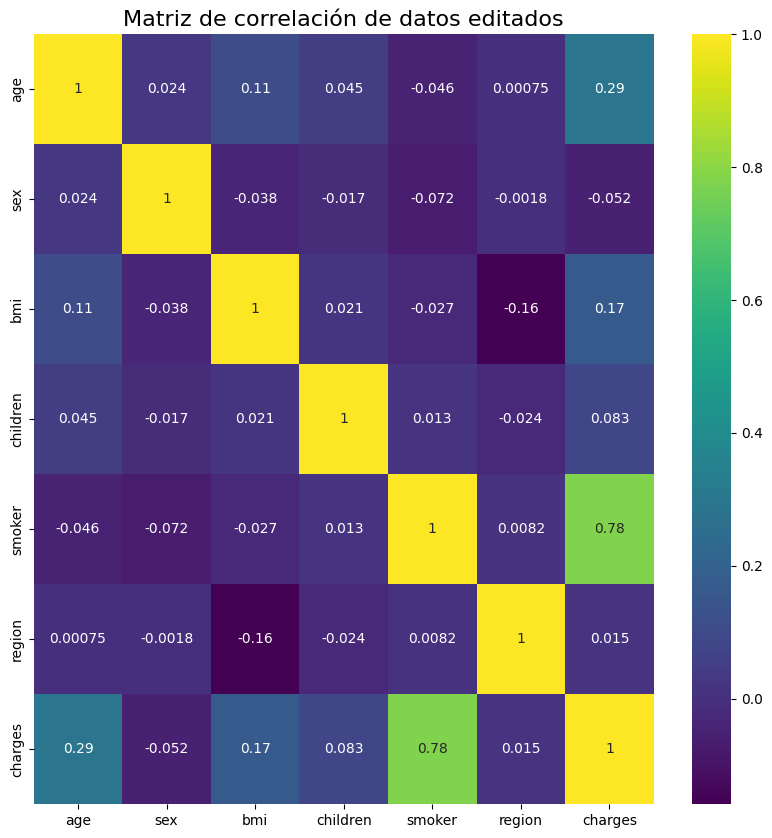

In [ ]:
f, ax = plt.subplots(1, 1, figsize=(10, 10))
ax = sns.heatmap(dataset_edit.corr(), annot=True, cmap='viridis')
ax.set_title('Matriz de correlación de datos editados', fontsize=16)


AHORITA PODEMOS OBSERVAR QUE NUESTRAS CORRELACIONES BAJARON, PERO AL GRAFICAR SE VE UNA MEJOR RELACIÓN PORQUE SE ELIMINARON VALORES QUE ESTABAN MUY AFUERA DE NUESTROS VALORES BASE

### Regresión Lineal de nuestros datos originales

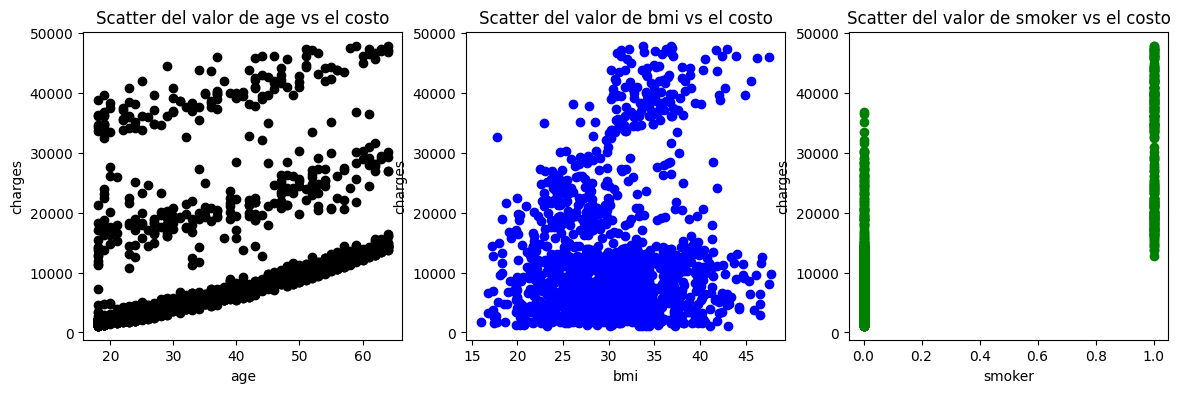

In [ ]:
plt.figure(figsize = (14,4))
plt.subplot(1,3,1)
plt.title('Scatter del valor de age vs el costo')
plt.ylabel('charges')
plt.xlabel('age')
plt.scatter(dataset_edit['age'], dataset_edit['charges'], color = 'black')

plt.subplot(1,3,2)
plt.title('Scatter del valor de bmi vs el costo')
plt.ylabel('charges')
plt.xlabel('bmi')
plt.scatter(dataset_edit['bmi'], dataset_edit['charges'], color = 'blue')


plt.subplot(1,3,3)
plt.title('Scatter del valor de smoker vs el costo')
plt.ylabel('charges')
plt.xlabel('smoker')
plt.scatter(dataset_edit['smoker'], dataset_edit['charges'], color = 'green')

# Podemos observar que smoker no sirve para graficar y que no tienen una distribución real
# PERO EN PÁGINAS DONDE TAMBIÉN OCUPAN ÉSTA BASE DE DATOS LA DIVIDEN TOMANDO COMO FUMADORES

### Dividir el dataset en 2

In [23]:
#dataset_original
dataset_smoker = dataset_edit.loc[dataset_edit['smoker'] == 1]
dataset_NO_smoker = dataset_edit.loc[dataset_edit['smoker'] == 0]
dataset_smoker.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Text(0.5, 1.0, 'Matriz de correlación de los FUMADORES')

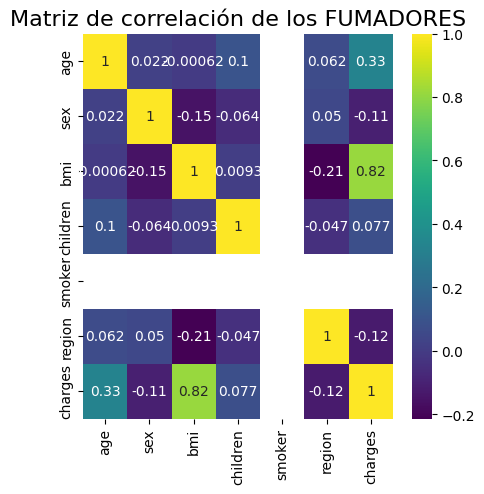

In [ ]:
f, ax = plt.subplots(1, 1, figsize=(5, 5))
ax = sns.heatmap(dataset_smoker.corr(), annot=True, cmap='viridis')
ax.set_title('Matriz de correlación de los FUMADORES', fontsize=16)

Text(0.5, 1.0, 'Matriz de correlación de los NO FUMADORES')

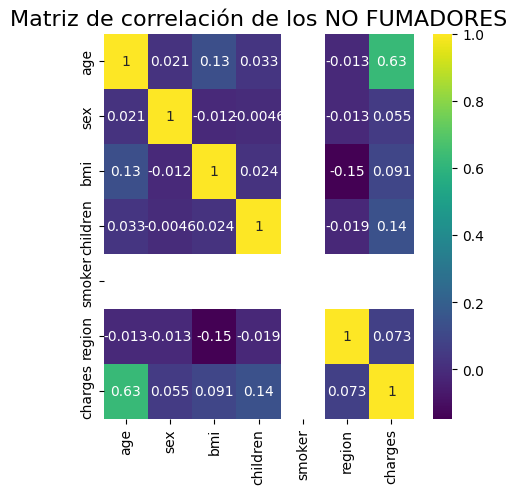

In [ ]:
f, ax = plt.subplots(1, 1, figsize=(5, 5))
ax = sns.heatmap(dataset_NO_smoker.corr(), annot=True, cmap='viridis')
ax.set_title('Matriz de correlación de los NO FUMADORES', fontsize=16)

Se está dividiendo en 2 porque dependiendo de si fuma o no, se encuentra una correlación diferente en las gráficas, y se podría predecir fácil en cada uno de los datasets por ejemplo, obtener la regresión de fumadores de age vs charges y aparte la regresión de no fumadores de age vs charges, y tal vez después sumarlas o dejar cada una sería bueno hacer pruebas.

Y así aplicarlo al de bmi vs charges.

También revisar si se puede encontrar una relación lineal con OTROS VALORES, como children vs charges o age vs bmi

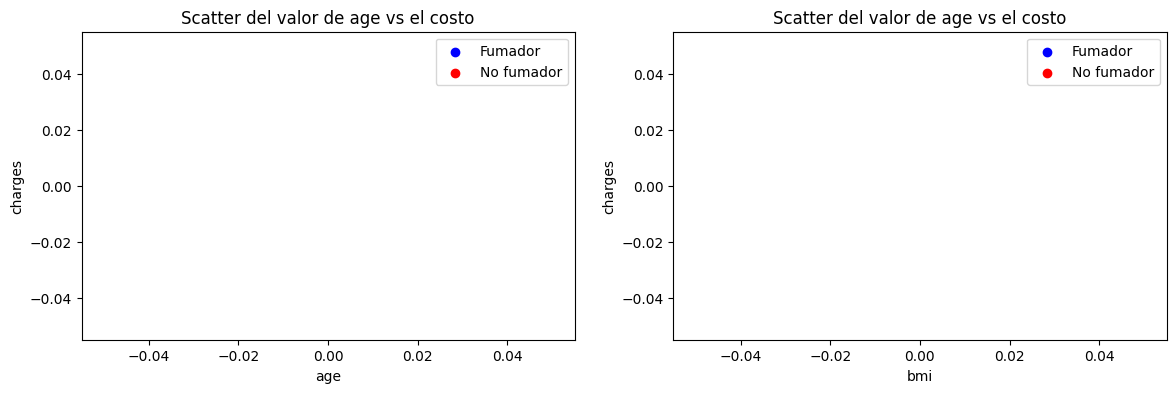

In [24]:
plt.figure(figsize = (14,4))
plt.subplot(1,2,1)
plt.title('Scatter del valor de age vs el costo')
plt.xlabel('age')
plt.ylabel('charges')
plt.scatter(dataset_smoker['age'], dataset_smoker['charges'], color='blue', label='Fumador')
plt.scatter(dataset_NO_smoker['age'], dataset_NO_smoker['charges'], color='red', label='No fumador')
plt.legend()

plt.subplot(1,2,2)
plt.title('Scatter del valor de age vs el costo')
plt.xlabel('bmi')
plt.ylabel('charges')
plt.scatter(dataset_smoker['bmi'], dataset_smoker['charges'], color='blue', label='Fumador')
plt.scatter(dataset_NO_smoker['bmi'], dataset_NO_smoker['charges'], color='red', label='No fumador')
plt.legend()

#Analisis por BMI

In [11]:
#dataset_original
dataset_smoker_bmi20 = dataset_smoker.loc[dataset_edit['bmi'] <= 20]
dataset_smoker_bmi40 = dataset_smoker.loc[dataset_edit['bmi'] >= 40]

dataset_smoker_obese = dataset_smoker.loc[dataset_edit['bmi'] > 40]
dataset_smoker_no_obese = dataset_smoker.loc[dataset_edit['bmi'] < 20]


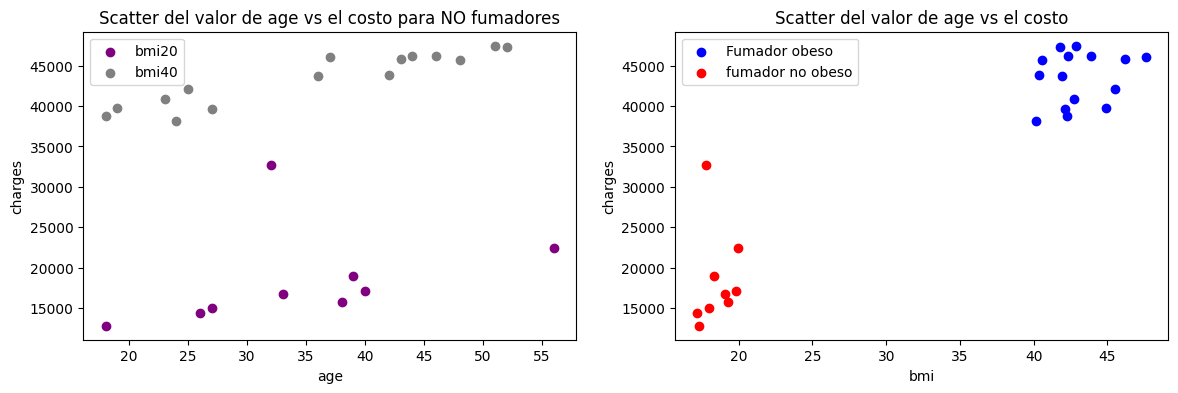

In [ ]:
plt.figure(figsize = (14,4))
plt.subplot(1,2,1)
plt.title('Scatter del valor de age vs el costo para NO fumadores')
plt.xlabel('age')
plt.ylabel('charges')
plt.scatter(dataset_smoker_bmi20['age'], dataset_smoker_bmi20['charges'], color='purple', label='bmi20')
plt.scatter(dataset_smoker_bmi40['age'], dataset_smoker_bmi40['charges'], color='gray', label='bmi40')
plt.legend()

plt.subplot(1,2,2)
plt.title('Scatter del valor de age vs el costo')
plt.xlabel('bmi')
plt.ylabel('charges')
plt.scatter(dataset_smoker_obese['bmi'], dataset_smoker_obese['charges'], color='blue', label='Fumador obeso')
plt.scatter(dataset_smoker_no_obese['bmi'], dataset_smoker_no_obese['charges'], color='red', label='fumador no obeso')
plt.legend()

# Analisis para fumadores obesos y no obesos

In [12]:
#dataset_original
dataset_smoker_obese = dataset_smoker.loc[dataset_edit['bmi'] >= 30]
dataset_smoker_no_obese = dataset_smoker.loc[dataset_edit['bmi'] < 30]
dataset_smoker_obese.dtypes

dataset_NO_smoker_obese = dataset_NO_smoker.loc[dataset_edit['bmi'] >= 30]
dataset_NO_smoker_no_obese = dataset_NO_smoker.loc[dataset_edit['bmi'] < 30]
dataset_NO_smoker_obese.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Text(0.5, 1.0, 'Matriz de correlación de los FUMADORES obesos')

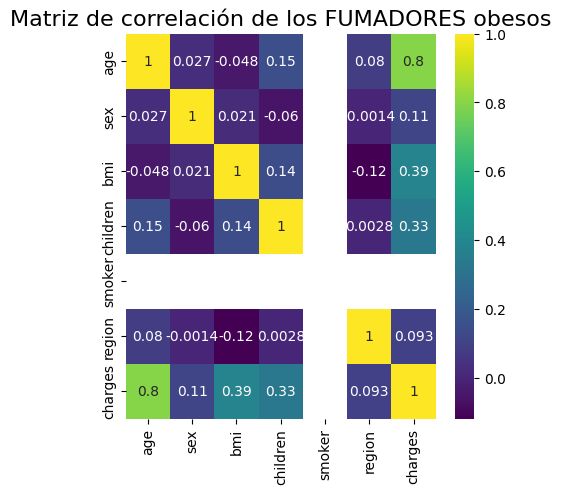

In [ ]:
f, ax = plt.subplots(1, 1, figsize=(5,5))
ax = sns.heatmap(dataset_smoker_obese.corr(), annot=True, cmap='viridis')
ax.set_title('Matriz de correlación de los FUMADORES obesos', fontsize=16)

Text(0.5, 1.0, 'Matriz de correlación de los FUMADORES NO obesos')

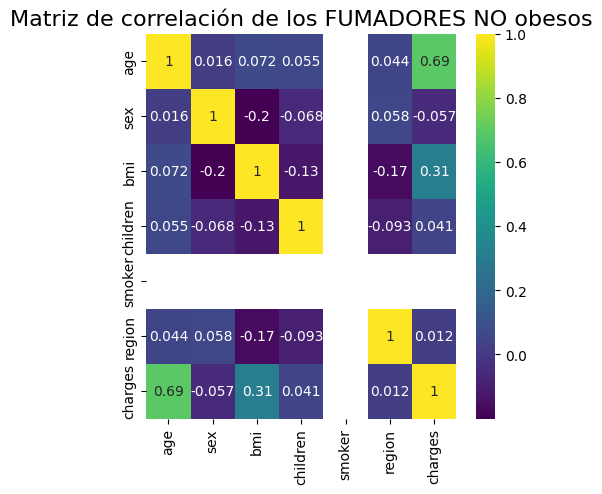

In [ ]:
f, ax = plt.subplots(1, 1, figsize=(5,5))
ax = sns.heatmap(dataset_smoker_no_obese.corr(), annot=True, cmap='viridis')
ax.set_title('Matriz de correlación de los FUMADORES NO obesos', fontsize=16)

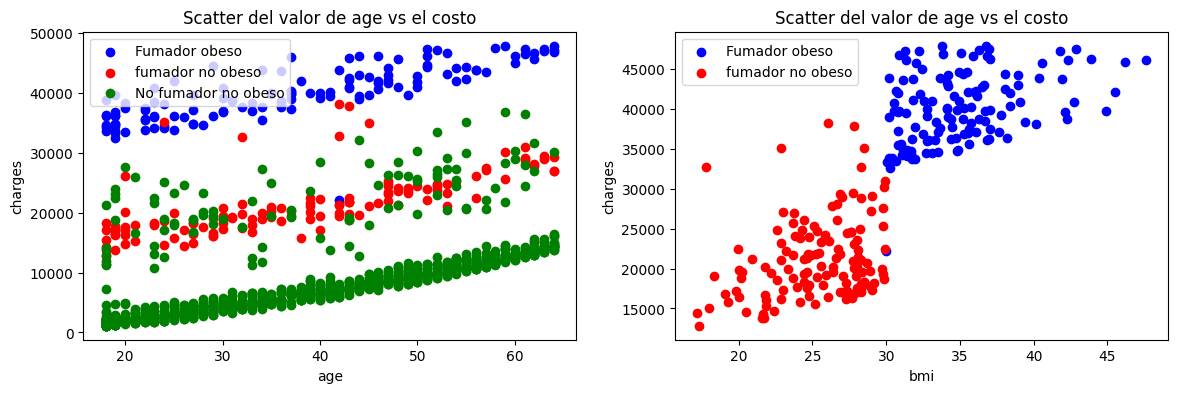

In [ ]:
plt.figure(figsize = (14,4))
plt.subplot(1,2,1)
plt.title('Scatter del valor de age vs el costo')
plt.xlabel('age')
plt.ylabel('charges')
plt.scatter(dataset_smoker_obese['age'], dataset_smoker_obese['charges'], color='blue', label='Fumador obeso')
plt.scatter(dataset_smoker_no_obese['age'], dataset_smoker_no_obese['charges'], color='red', label='fumador no obeso')
plt.scatter(dataset_NO_smoker['age'], dataset_NO_smoker['charges'], color='green', label='No fumador no obeso')
plt.legend()

plt.subplot(1,2,2)
plt.title('Scatter del valor de age vs el costo')
plt.xlabel('bmi')
plt.ylabel('charges')
plt.scatter(dataset_smoker_obese['bmi'], dataset_smoker_obese['charges'], color='blue', label='Fumador obeso')
plt.scatter(dataset_smoker_no_obese['bmi'], dataset_smoker_no_obese['charges'], color='red', label='fumador no obeso')
plt.legend()



plt.legend()

# Analisis para NO FUMADORES obesos y no obesos

In [17]:
#dataset_original
dataset_NO_smoker_obese = dataset_NO_smoker.loc[dataset_edit['bmi'] >= 30]
dataset_NO_smoker_no_obese = dataset_NO_smoker.loc[dataset_edit['bmi'] < 30]
dataset_NO_smoker_obese.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Text(0.5, 1.0, 'Matriz de correlación de los NO FUMADORES obesos')

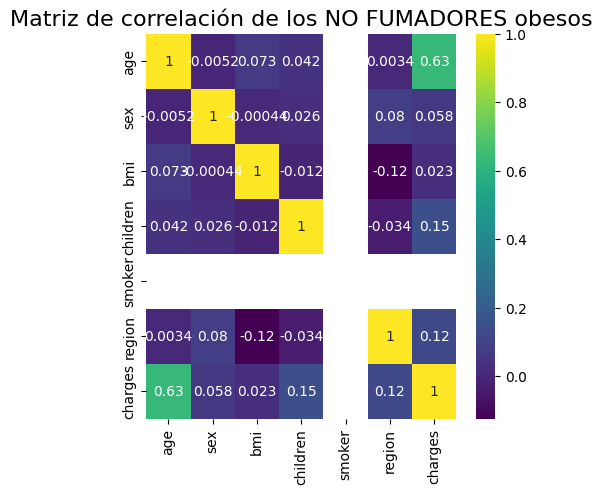

In [ ]:
f, ax = plt.subplots(1, 1, figsize=(5,5))
ax = sns.heatmap(dataset_NO_smoker_obese.corr(), annot=True, cmap='viridis')
ax.set_title('Matriz de correlación de los NO FUMADORES obesos', fontsize=16)

Text(0.5, 1.0, 'Matriz de correlación de los NO FUMADORES no obesos')

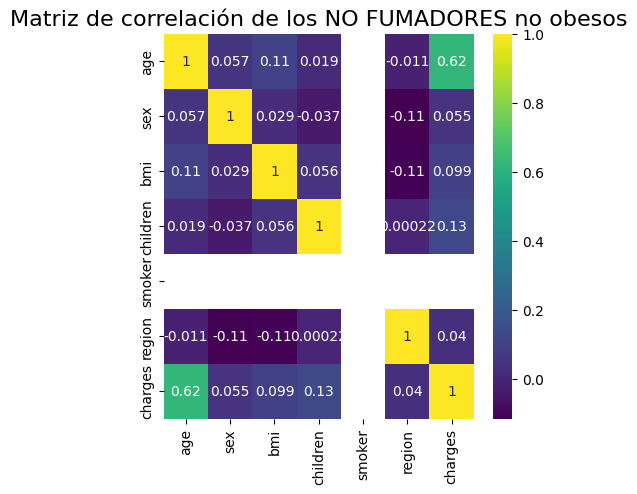

In [ ]:
f, ax = plt.subplots(1, 1, figsize=(5,5))
ax = sns.heatmap(dataset_NO_smoker_no_obese.corr(), annot=True, cmap='viridis')
ax.set_title('Matriz de correlación de los NO FUMADORES no obesos', fontsize=16)

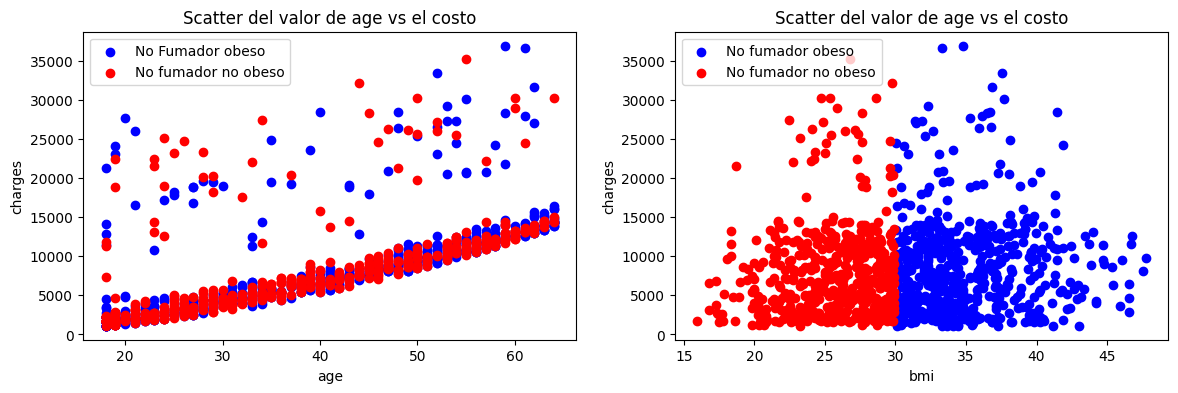

In [ ]:
plt.figure(figsize = (14,4))
plt.subplot(1,2,1)
plt.title('Scatter del valor de age vs el costo')
plt.xlabel('age')
plt.ylabel('charges')
plt.scatter(dataset_NO_smoker_obese['age'], dataset_NO_smoker_obese['charges'], color='blue', label='No Fumador obeso')
plt.scatter(dataset_NO_smoker_no_obese['age'], dataset_NO_smoker_no_obese['charges'], color='red', label='No fumador no obeso')
plt.legend()

plt.subplot(1,2,2)
plt.title('Scatter del valor de age vs el costo')
plt.xlabel('bmi')
plt.ylabel('charges')
plt.scatter(dataset_NO_smoker_obese['bmi'], dataset_NO_smoker_obese['charges'], color='blue', label='No fumador obeso')
plt.scatter(dataset_NO_smoker_no_obese['bmi'], dataset_NO_smoker_no_obese['charges'], color='red', label='No fumador no obeso')
plt.legend()

#analisis por hijos

In [ ]:
#dataset_original
dataset_NO_smoker_0_children = dataset_NO_smoker.loc[dataset_edit['children'] == 0]
dataset_NO_smoker_1_children = dataset_NO_smoker.loc[dataset_edit['children'] == 1]
dataset_NO_smoker_2_children = dataset_NO_smoker.loc[dataset_edit['children'] == 2]
dataset_NO_smoker_3_children = dataset_NO_smoker.loc[dataset_edit['children'] == 3]
dataset_NO_smoker_4_children = dataset_NO_smoker.loc[dataset_edit['children'] == 4]
dataset_NO_smoker_5_children = dataset_NO_smoker.loc[dataset_edit['children'] == 5]


age           int64
sex           int64
bmi         float64
children      int64
smoker        int64
region        int64
charges     float64
dtype: object

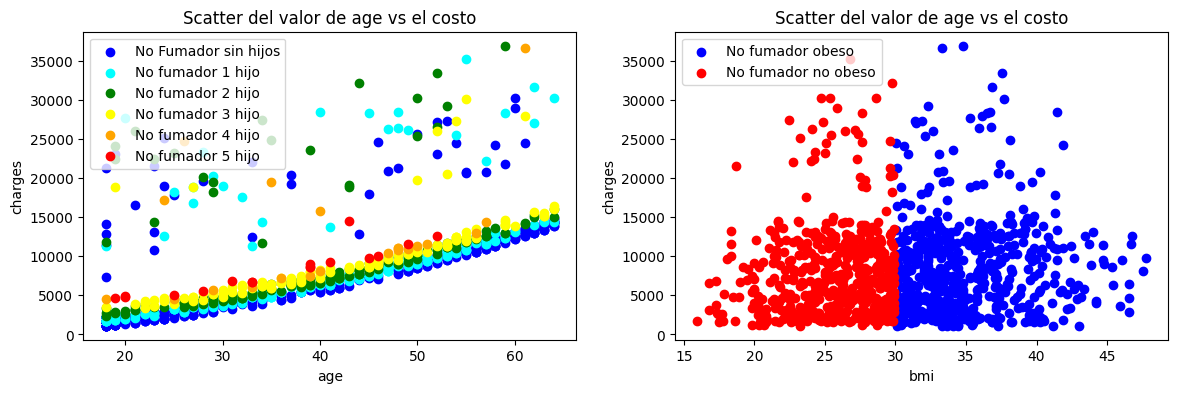

In [ ]:
plt.figure(figsize = (14,4))
plt.subplot(1,2,1)
plt.title('Scatter del valor de age vs el costo')
plt.xlabel('age')
plt.ylabel('charges')
plt.scatter(dataset_NO_smoker_0_children['age'], dataset_NO_smoker_0_children['charges'], color='blue', label='No Fumador sin hijos')
plt.scatter(dataset_NO_smoker_1_children['age'], dataset_NO_smoker_1_children['charges'], color='cyan', label='No fumador 1 hijo')
plt.scatter(dataset_NO_smoker_2_children['age'], dataset_NO_smoker_2_children['charges'], color='green', label='No fumador 2 hijo')
plt.scatter(dataset_NO_smoker_3_children['age'], dataset_NO_smoker_3_children['charges'], color='yellow', label='No fumador 3 hijo')
plt.scatter(dataset_NO_smoker_4_children['age'], dataset_NO_smoker_4_children['charges'], color='orange', label='No fumador 4 hijo')
plt.scatter(dataset_NO_smoker_5_children['age'], dataset_NO_smoker_5_children['charges'], color='red', label='No fumador 5 hijo')
plt.legend()

plt.subplot(1,2,2)
plt.title('Scatter del valor de age vs el costo')
plt.xlabel('bmi')
plt.ylabel('charges')
plt.scatter(dataset_NO_smoker_obese['bmi'], dataset_NO_smoker_obese['charges'], color='blue', label='No fumador obeso')
plt.scatter(dataset_NO_smoker_no_obese['bmi'], dataset_NO_smoker_no_obese['charges'], color='red', label='No fumador no obeso')
plt.legend()

#analisis por hijos de todo el dataset

In [ ]:
#dataset_original
dataset_age = dataset_edit.loc[dataset_edit['age'] == 49]
# dataset_age_49 = dataset_edit.loc[dataset_edit['age'] == 49]
# dataset_age_25 = dataset_edit.loc[dataset_edit['age'] == 25]
print(dataset_edit)
dataset_arr = np.array(dataset_edit)
print(dataset_arr[:,6])
dataset_min_charge = np.min(dataset_arr[:,6])
print(dataset_min_charge)
print(dataset_edit['charges'] - dataset_min_charge)
# dataset_edit = np.min(dataset_edit, axis='charges')

      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1317 rows x 7 columns]
[16884.924 1725.5523 4449.462 ... 1629.8335 2007.945 29141.3603]
1121.8739
0       15763.05010
1         603.67840
2        3327.58810
3       20862.59671
4        2744.98

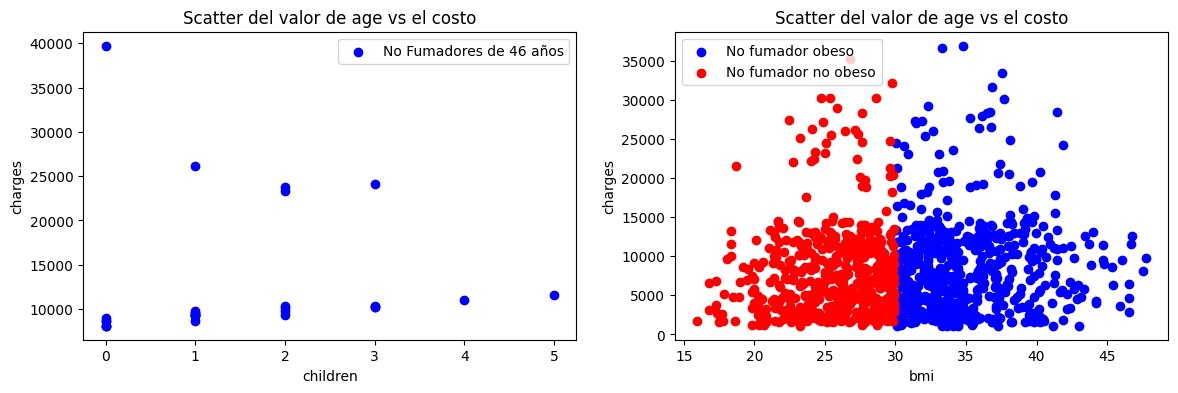

In [ ]:
plt.figure(figsize = (14,4))
plt.subplot(1,2,1)
plt.title('Scatter del valor de age vs el costo')
plt.xlabel('children')
plt.ylabel('charges')
plt.scatter(dataset_age['children'], dataset_age['charges'], color='blue', label='No Fumadores de 46 años')

plt.legend()

plt.subplot(1,2,2)
plt.title('Scatter del valor de age vs el costo')
plt.xlabel('bmi')
plt.ylabel('charges')
plt.scatter(dataset_NO_smoker_obese['bmi'], dataset_NO_smoker_obese['charges'], color='blue', label='No fumador obeso')
plt.scatter(dataset_NO_smoker_no_obese['bmi'], dataset_NO_smoker_no_obese['charges'], color='red', label='No fumador no obeso')
plt.legend()

# entrenamiento

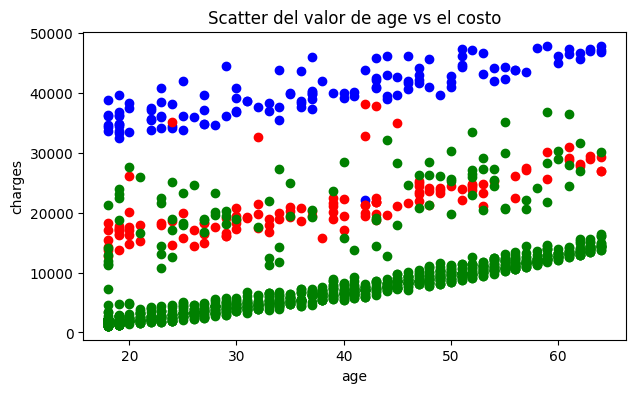

In [ ]:
plt.figure(figsize = (7,4))
# plt.subplot(1,2,1)
plt.title('Scatter del valor de age vs el costo')
plt.xlabel('age')
plt.ylabel('charges')
plt.scatter(dataset_smoker_obese['age'], dataset_smoker_obese['charges'], color='blue', label='Fumador obeso')
plt.scatter(dataset_smoker_no_obese['age'], dataset_smoker_no_obese['charges'], color='red', label='fumador no obeso')
plt.scatter(dataset_NO_smoker['age'], dataset_NO_smoker['charges'], color='green', label='No fumador no obeso')
plt.show()

In [21]:
import numpy as np
def hip(theta_0,theta_1,x):
    h = theta_1*x + theta_0
    return h

def MSE(theta0,theta1,x,y):
    block = hip(theta0,theta1,x) - y

    m = len(x)
    return sum(block*block)/(2*m)

def MAE(theta0,theta1,x,y):
    block = hip(theta0,theta1,x) - y

    m = len(x)
    return (1/2*m)*sum(abs(block))



$h_\theta(x)=\theta_1 x + \theta_0$

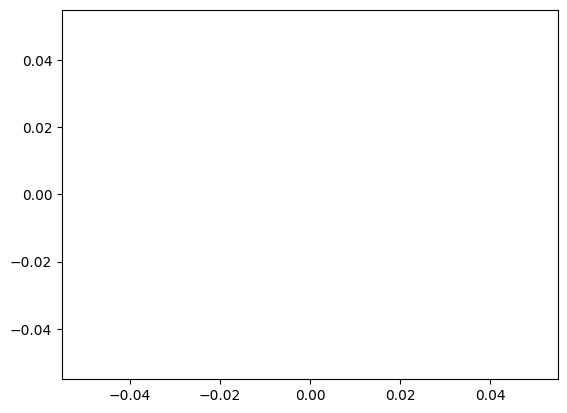

In [22]:

theta0=400
theta1=260
# x = dataset_NO_smoker['age']

x = np.array(dataset_NO_smoker['age'])
y = np.array(dataset_NO_smoker['charges'])
h = hip(theta0,theta1,x)
# costo = MSE(theta0 , theta1 , x , y)

import matplotlib.pyplot as plt
plt.scatter(x,y)
plt.plot(x,h,c='red')
plt.show()

quería eliminar todos los outliers arriba de la linea roja

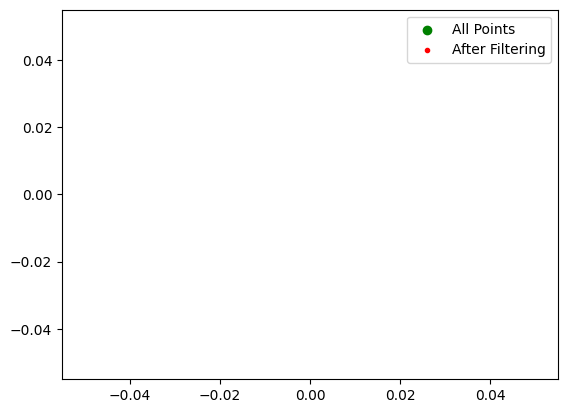

In [25]:
n = len(x)
filteredx = list()
filteredy = list()
plt.scatter(x, y, marker='o', color='g', label="All Points")
for i in range(1,n,1):
    h = hip(theta0,theta1,x[i])
    if y[i] < h:
        filteredx.append(x[i])
        filteredy.append(y[i])
plt.scatter(filteredx, filteredy, marker='.', color='r', label="After Filtering")
h = hip(theta0,theta1,x)
plt.plot(x,h, linewidth=1, linestyle='-')
plt.legend()
plt.show()

# eliminacion de outliers

In [ ]:
#remover outliers
def reject_outliers(data):
 u = np.mean(data['charges'])
 s = np.std(data['charges'])
 data_filtered = data[(data["charges"]>(u-2*s)) & (data["charges"]<(u+2*s))]
 return data_filtered


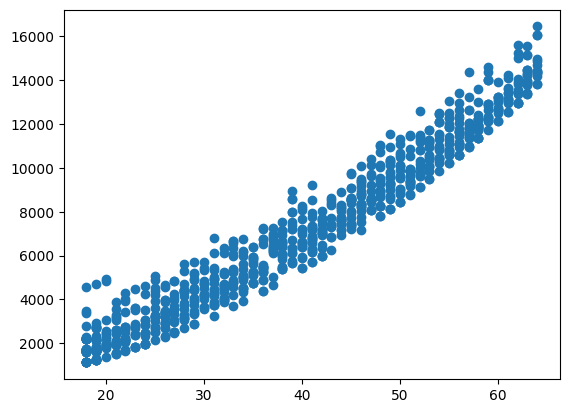

In [ ]:
# dataset_NO_smokers_filtered = reject_outliers(dataset_NO_smoker)
# import matplotlib.pyplot as plt
# x = dataset_NO_smokers_filtered['age']
# y = dataset_NO_smokers_filtered['charges']
x = filteredx
y = filteredy
plt.scatter(x,y)
plt.show()

#entrenamiento no fumadores

In [ ]:
#iguala los parametros theta a los de la linea
theta_0=theta0
theta_1=theta1

In [ ]:
# y=data['Sales']
# x=data['TV']

# theta_0=7.032593038945596
# theta_1=0.04753664302381351

m = len(filteredy)
x=np.array(x)
y=np.array(y)
mse = MSE(theta_0,theta_1,x,y)

alpha = 6e-4
epochs = 10000;
list_theta0 = []
list_theta1 = []
list_mse = []

list_theta0.append(theta_0)
list_theta1.append(theta_1)
list_mse.append(mse)

for epoch in range(epochs):
    theta_0 = theta_0 - (alpha/m)*sum( hip(theta_0,theta_1,x) - y )
    theta_1 = theta_1 - (alpha/m)*sum( ( hip(theta_0,theta_1,x) - y )*x )
    mse = MSE(theta_0,theta_1,x,y)
    list_theta0.append(theta_0)
    list_theta1.append(theta_1)
    list_mse.append(mse)

# print("list theta0 max value: "+str(max(list_theta0))+", min value: "+str(min(list_theta0)))
print("list theta0 first value: "+str(list_theta0[0])+", last value: "+str(list_theta0[-1]))
# print("list theta1 max value: "+str(max(list_theta1))+", min value: "+str(min(list_theta1)))
print("list theta1 first value: "+str(list_theta1[0])+", last value: "+str(list_theta1[-1]))
# print("list MSE max value: "+str(max(list_mse))+", min value: "+str(min(list_mse)))
print("list MSE first value: "+str(list_mse[0])+", last value: "+str(list_mse[-1]))


list theta0 first value: -1820.3395551761016, last value: -2673.547726844824
list theta1 first value: 261.263793489543, last value: 249.2193304889126
list MSE first value: 1369923.690475742, last value: 388498.6979741967


# grafica de la regresion

theta_0: -2673.547726844824 theta_1: 249.2193304889126
Costo:  388498.6979741967


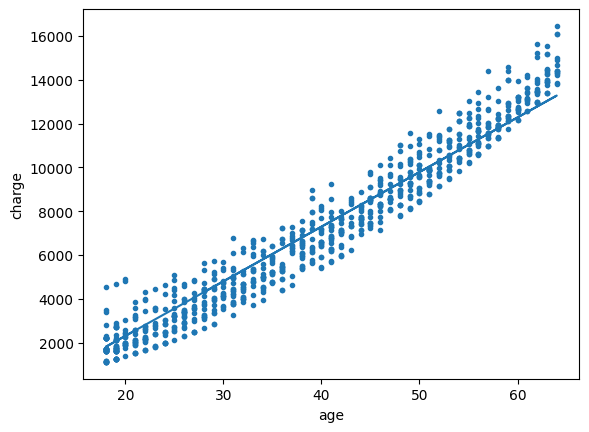

In [ ]:
# columns_lst = list(data.columns)[1:5]
# theta0=0.67
# theta1=13
# y = columna ventas x = es columna tv, theta1=80, theta0=0.05
# x = data['TV']
h = hip(theta_0,theta_1,x)

# y = data['# Shares']
costo = MSE(theta_0 , theta_1 , x , y)
print("theta_0: "+str(theta_0) \
        +" theta_1: "+str(theta_1))
print("Costo: ",costo)

import matplotlib.pyplot as plt
plt.xlabel('age')
plt.ylabel('charge')
plt.scatter(x,y,marker='.')
plt.plot(x,h)
plt.show()

R-squared

In [ ]:
R2 = 1 - sum((h-y)**2)/sum((y-np.mean(y))**2)
print(R2)

0.947956873270622


# grafica del costo

511883.20876297064


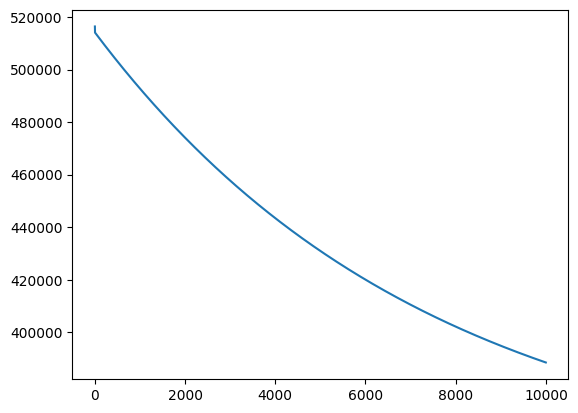

In [ ]:
# columns_lst = list(data.columns)[1:5]
# theta0=0.67
# theta1=13
# y = columna ventas x = es columna tv, theta1=80, theta0=0.05
# x = data['TV']
h = hip(theta_0,theta_1,x)
print(list_mse[100])
# y = data['# Shares']
# costo = MSE(theta_0 , theta_1 , x , y)
# print("Costo: ",costo)

import matplotlib.pyplot as plt
# x = np.arange(-0,100,1)
# plt.scatter(x,y,marker='.')
plt.plot(list_mse[1:10000])
plt.show()

# entrenamiento fumadores no obesos

Costo: 7235670.8943373365


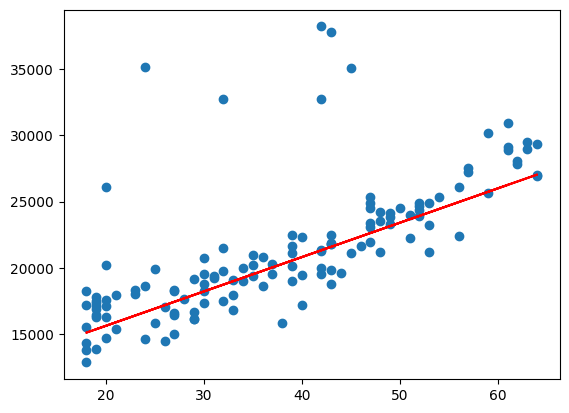

In [ ]:
# columns_lst = list(data.columns)[1:5]
theta0=10400
theta1=260
# y = columna ventas x = es columna tv, theta1=80, theta0=0.05
x = dataset_smoker_no_obese['age']
y = dataset_smoker_no_obese['charges']

h = hip(theta0,theta1,x)
costo = MSE(theta0 , theta1 , x , y)
print("Costo: "+str(costo))

import matplotlib.pyplot as plt
plt.scatter(x,y)
plt.plot(x,h,c='red')
plt.show()

In [ ]:
theta_0=theta0
theta_1=theta1

In [ ]:
# y=data['Sales']
# x=data['TV']

# theta_0=7.032593038945596
# theta_1=0.04753664302381351

m = len(dataset_smoker_no_obese['charges'])
mse = MSE(theta_0,theta_1,x,y)

alpha = 6e-4
epochs = 10000;
list_theta0 = []
list_theta1 = []
list_mse = []

list_theta0.append(theta_0)
list_theta1.append(theta_1)
list_mse.append(mse)

for epoch in range(epochs):
    theta_0 = theta_0 - (alpha/m)*sum( hip(theta_0,theta_1,x) - y )
    theta_1 = theta_1 - (alpha/m)*sum( ( hip(theta_0,theta_1,x) - y )*x )
    mse = MSE(theta_0,theta_1,x,y)
    list_theta0.append(theta_0)
    list_theta1.append(theta_1)
    list_mse.append(mse)

# print("list theta0 max value: "+str(max(list_theta0))+", min value: "+str(min(list_theta0)))
print("list theta0 first value: "+str(list_theta0[0])+", last value: "+str(list_theta0[-1]))
# print("list theta1 max value: "+str(max(list_theta1))+", min value: "+str(min(list_theta1)))
print("list theta1 first value: "+str(list_theta1[0])+", last value: "+str(list_theta1[-1]))
# print("list MSE max value: "+str(max(list_mse))+", min value: "+str(min(list_mse)))
print("list MSE first value: "+str(list_mse[0])+", last value: "+str(list_mse[-1]))

list theta0 first value: 10400, last value: 10940.534454326471
list theta1 first value: 260, last value: 273.8499191000105
list MSE first value: 7235670.8943373365, last value: 6617694.465312717


#grafica de la regresion

theta_0: 8106.422679047132 theta_1: 340.3701975205829
Costo:  7246684.825227142


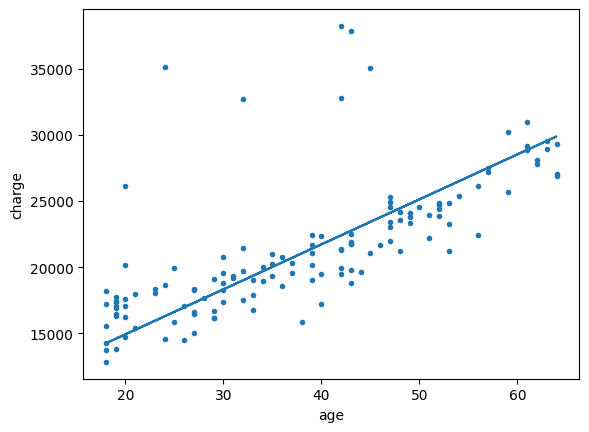

In [ ]:
h = hip(theta_0,theta_1,x)

# y = data['# Shares']
costo = MSE(theta_0 , theta_1 , x , y)
print("theta_0: "+str(theta_0) \
        +" theta_1: "+str(theta_1))
print("Costo: ",costo)

import matplotlib.pyplot as plt
plt.xlabel('age')
plt.ylabel('charge')
plt.scatter(x,y,marker='.')
plt.plot(x,h)
plt.show()

# entrenamiento fumadores obesos

Costo: 3630662.4914836893


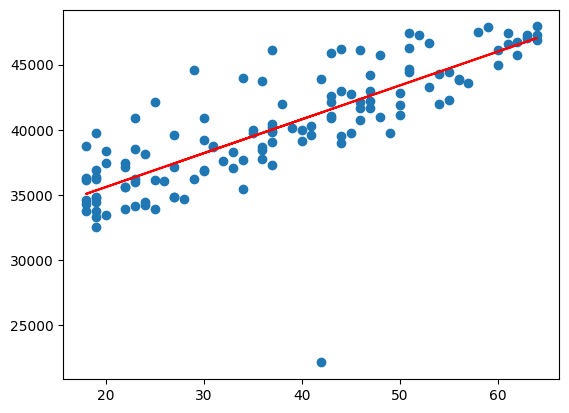

In [ ]:
# columns_lst = list(data.columns)[1:5]
theta0=30400
theta1=260
# y = columna ventas x = es columna tv, theta1=80, theta0=0.05
x = dataset_smoker_obese['age']
y = dataset_smoker_obese['charges']

h = hip(theta0,theta1,x)
costo = MSE(theta0 , theta1 , x , y)
print("Costo: "+str(costo))

import matplotlib.pyplot as plt
plt.scatter(x,y)
plt.plot(x,h,c='red')
plt.show()

In [ ]:
theta_0=theta0
theta_1=theta1

In [ ]:
# y=data['Sales']
# x=data['TV']

# theta_0=7.032593038945596
# theta_1=0.04753664302381351

m = len(dataset_smoker_no_obese['charges'])
mse = MSE(theta_0,theta_1,x,y)

alpha = 6e-4
epochs = 10000;
list_theta0 = []
list_theta1 = []
list_mse = []

list_theta0.append(theta_0)
list_theta1.append(theta_1)
list_mse.append(mse)

for epoch in range(epochs):
    theta_0 = theta_0 - (alpha/m)*sum( hip(theta_0,theta_1,x) - y )
    theta_1 = theta_1 - (alpha/m)*sum( ( hip(theta_0,theta_1,x) - y )*x )
    mse = MSE(theta_0,theta_1,x,y)
    list_theta0.append(theta_0)
    list_theta1.append(theta_1)
    list_mse.append(mse)

# print("list theta0 max value: "+str(max(list_theta0))+", min value: "+str(min(list_theta0)))
print("list theta0 first value: "+str(list_theta0[0])+", last value: "+str(list_theta0[-1]))
# print("list theta1 max value: "+str(max(list_theta1))+", min value: "+str(min(list_theta1)))
print("list theta1 first value: "+str(list_theta1[0])+", last value: "+str(list_theta1[-1]))
# print("list MSE max value: "+str(max(list_mse))+", min value: "+str(min(list_mse)))
print("list MSE first value: "+str(list_mse[0])+", last value: "+str(list_mse[-1]))

list theta0 first value: 30400, last value: 30423.586233757454
list theta1 first value: 260, last value: 257.7941859472228
list MSE first value: 3630662.4914836893, last value: 3628359.971350383


#grafica de la regresion

theta_0: 30423.586233757454 theta_1: 257.7941859472228
Costo:  3628359.971350383


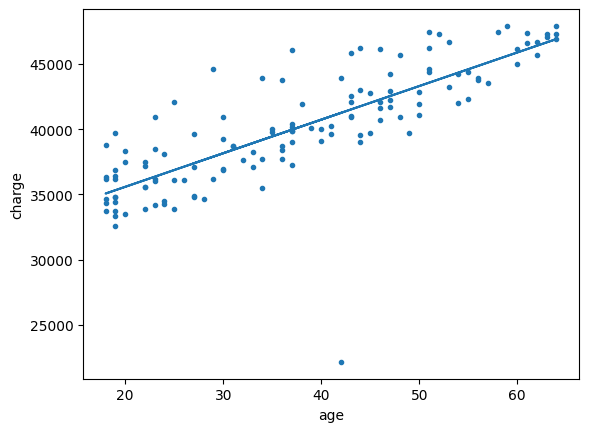

In [ ]:
h = hip(theta_0,theta_1,x)

# y = data['# Shares']
costo = MSE(theta_0 , theta_1 , x , y)
print("theta_0: "+str(theta_0) \
        +" theta_1: "+str(theta_1))
print("Costo: ",costo)

import matplotlib.pyplot as plt
plt.xlabel('age')
plt.ylabel('charge')
plt.scatter(x,y,marker='.')
plt.plot(x,h)
plt.show()